In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.circuit import ParameterVector

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, LeakyReLU

# import sys
# sys.path.insert(1, '/home/fredo/qgan-lamarr/qgan_tests')
# from distributions import MinMaxBinning, SingleGaussian, MixedGaussian
# from qgan import QGAN

2026-05-08 08:55:40.773468: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 08:55:41.638761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778223341.873883    7319 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778223341.931679    7319 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778223342.684713    7319 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Distribution embedding

In [2]:
# num_qubits = 3
# nbins = 2**num_qubits

# def sample_dist(_size, _nbins):
#     _sample = MixedGaussian(mean = [-1.0, 0.0, 1.0], sd = [0.25, 0.25, 0.25], shots = _size)
#     return MinMaxBinning(_sample, _nbins)

# sample = sample_dist(2**10-1, nbins)
# print(sample)
# plot_histogram(sample)

In [3]:
from load_dp import load_dp
import matplotlib.pyplot as plt

dp = load_dp((20000, 21000), 'h')

Found 1 files
['/home/fredo/qgan-lamarr/LamarrTraining.root']
Data loaded


In [6]:
lim = 750
dpr = dp.loc[lambda x : (x <= lim) & (x >= -lim)]

(array([  15.,   17.,   38.,   32.,   74.,  255., 1334., 5097., 6409.,
        1899.,  356.,   89.,   39.,   30.,   19.,   22.]),
 array([-746.65429688, -653.69030762, -560.72631836, -467.7623291 ,
        -374.79833984, -281.83435059, -188.87036133,  -95.90637207,
          -2.94238281,   90.02160645,  182.9855957 ,  275.94958496,
         368.91357422,  461.87756348,  554.84155273,  647.80554199,
         740.76953125]),
 <BarContainer object of 16 artists>)

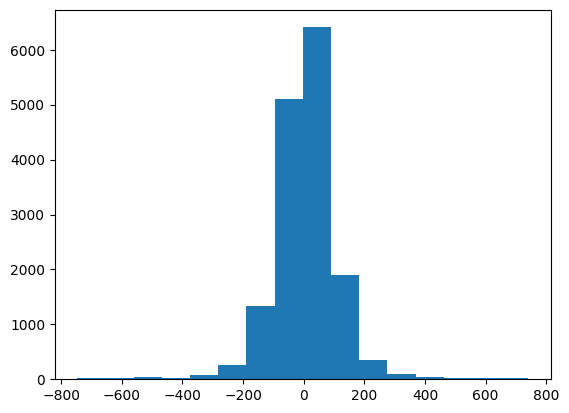

In [9]:
num_qubits = 4
nbins = 2**num_qubits
plt.hist(dpr, bins = nbins)

In [10]:
def norm_binning(_data, _nbins):
    
    data_interval = max(_data) - min(_data)
    bin_length = float(data_interval)/float(_nbins)
    
    binned_data = {}
    for b in range(_nbins):
        bin_min_val = min(_data) + bin_length * b
        bin_max_val = min(_data) + bin_length * (b+1)
        
        bin_counts = sum(1 for x in _data if bin_min_val <= x < bin_max_val)
        if b == _nbins-1: 
            bin_counts += sum(1 for x in _data if x == bin_max_val)

        binned_data.update({format(int(b), f'0{int(np.log2(_nbins))}b') : bin_counts})
    return binned_data

def sample_dist(_size, _nbins):
    _sample = np.random.choice(dpr, size = _size, replace=True)
    return norm_binning(_sample, _nbins)

# QGAN networks

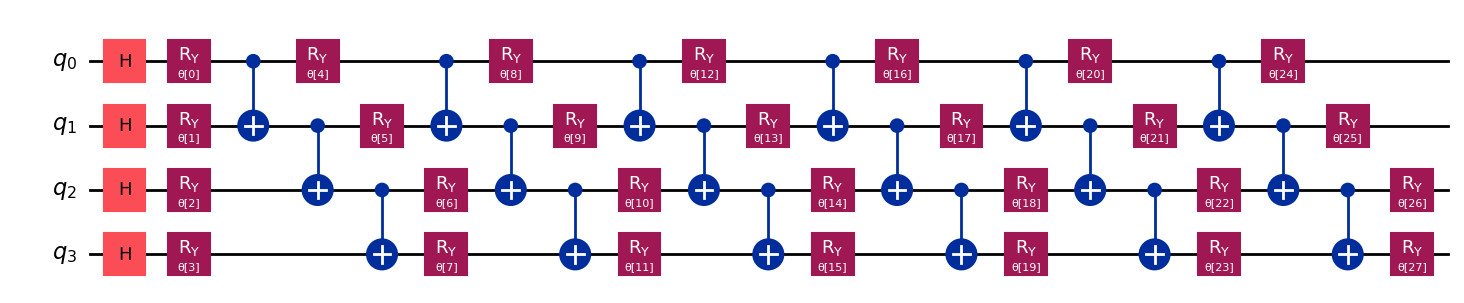

In [14]:
from qiskit.circuit import ParameterVector

reps = 6
qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
theta = ParameterVector("θ", length = (reps + 1) * num_qubits * 2)

p = 0

for q in range(num_qubits):
        qc.ry(theta[q], q)
        p += 1
for r in range(reps):

    for q in range(num_qubits-1):
        qc.cx(q%num_qubits, (q + 1)%num_qubits)
    for q in range(num_qubits):
        qc.ry(theta[p], q)
        p += 1
        
    

qc.draw("mpl")

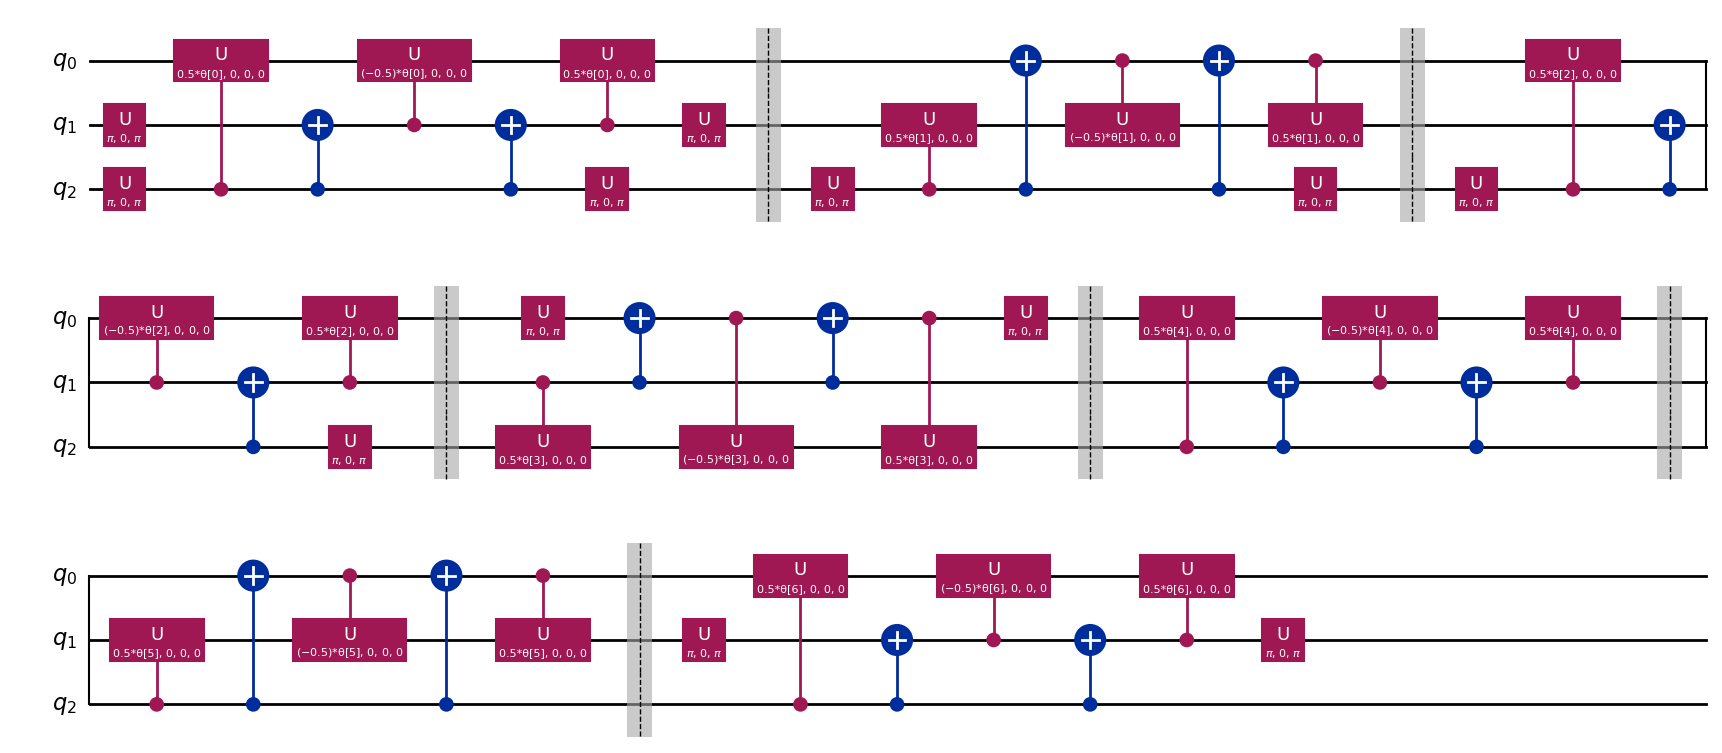

In [2]:
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RYGate

thetas = ParameterVector('θ', 7)

def CCRY(qc, ob, targets):
    global p, thetas
    CCRY = RYGate(thetas[p]).control(2)
    num_qubits = qc.num_qubits
    ports = list(range(num_qubits))
    ports.pop(ports.index(ob))
    p += 1
    gate = QuantumCircuit(num_qubits)
    for t in ports:
        if targets[ports.index(t)] == 0:
            gate.x(t)
    ports.append(ob) 
    gate.append(CCRY, ports)
    ports.pop(ports.index(ob))
    for t in ports:
        if targets[ports.index(t)] == 0:
            gate.x(t)
    return gate

p = 0
qc = QuantumCircuit(3)
qc.append(CCRY(qc, 0, [0,0]), range(3))
qc.barrier()
qc.append(CCRY(qc, 1, [1,0]), range(3))
qc.barrier()
qc.append(CCRY(qc, 0, [1,0]), range(3))
qc.barrier()
qc.append(CCRY(qc, 2, [0,1]), range(3))
qc.barrier()
qc.append(CCRY(qc, 0, [1,1]), range(3))
qc.barrier()
qc.append(CCRY(qc, 1, [1,1]), range(3))
qc.barrier()
qc.append(CCRY(qc, 0, [0,1]), range(3))
qc = qc.decompose().decompose()
qc.draw("mpl")

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, LeakyReLU

discriminator = Sequential([
    InputLayer(shape=(nbins,)),
    Dense(50),
    LeakyReLU(),
    Dense(1, activation='linear') 
])

discriminator.summary()

2026-04-28 08:52:52.023983: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 901 (3.52 KB)

 Trainable params: 901 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from qgan import QGAN
model = QGAN(num_qubits =int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist,
             wass = True)

In [18]:
epochs = 2000
model.discriminator_lr = 1e-4
model.fit(epochs = epochs, shots = 2**10, step_balance = 10.0, manager = True, opt = 'ADAM_PSR', lr = 1e-3)

Monitoring run: run_20260428_085303
Training started


100%|██████████| 2000/2000 [34:12<00:00,  1.03s/it]

Training completed


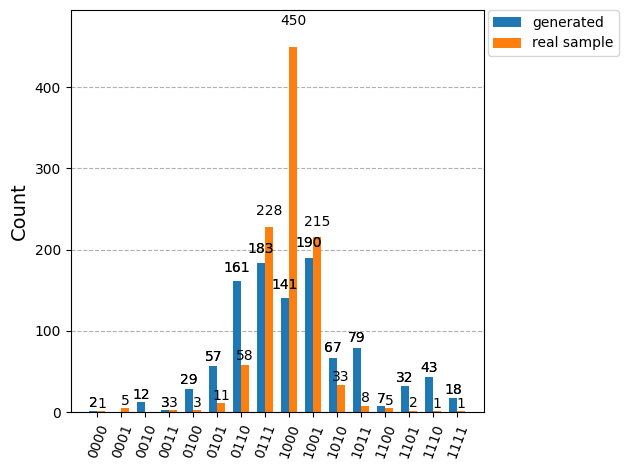

In [20]:
nsamples = 2**10
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])